<div align="center">
  <a href="https://pageindex.ai/developer">
    <img src="https://github.com/user-attachments/assets/bae02956-6c4e-4a0b-adea-257b0be4aaa1" width="100%" alt="PageIndex — Vectorless, Reasoning-based RAG">
  </a>
  <p>
    <a href="https://pageindex.ai/developer">🌐 Website</a> &nbsp; · &nbsp;
    <a href="https://developer.pageindex.ai/">☁️ Cloud</a> &nbsp; · &nbsp;
    <a href="https://docs.pageindex.ai/">📖 Docs</a> &nbsp; · &nbsp;
    <a href="https://github.com/VectifyAI/PageIndex">⭐ GitHub</a> &nbsp; · &nbsp;
    <a href="https://pageindex.ai/contact">✉️ Contact</a>
  </p>
</div>

---

# PageIndex Multimodal Retrieval & Understanding

**Retrieve the visual evidence. Understand what it shows.**

Documents contain more than text: images, charts, and diagrams can carry information that is essential to answering a question. This notebook demonstrates how **PageIndex Cloud** and a vision-capable chat model work together to retrieve document images and use their visual content to answer questions.

Using the PageIndex SDK, we ask about an image in an existing cloud-hosted document, follow the retrieval tool calls, and display the retrieved images alongside the model’s answer.

1. **Set up** — Install the SDK and configure your client with a vision-capable chat model.
2. **Retrieve & understand** — Ask about a document image and watch the model retrieve visual evidence and describe it.
3. **Inspect the images** — Display the returned images to compare the visual evidence with the answer.
4. **Review usage (optional)** — Inspect token usage and estimate the model cost of the query.

**Before you start:** Have your OpenAI API key ready. This demo uses an existing document on PageIndex Cloud with the supplied demo access key, so no upload or local indexing is needed.


## 01 · Set up

Install the latest PageIndex SDK.


In [ ]:
!pip install -U pageindex

### Configure your client

Set your API keys and choose a vision-capable `MODEL`. PageIndex Cloud provides access to the document and its images; the chat model uses the retrieval tools to find relevant content and interpret the visual evidence.


In [ ]:
import os
from pageindex import PageIndexClient

os.environ["PAGEINDEX_API_KEY"]="pageindex_demo_readonly_key"
os.environ["OPENAI_API_KEY"] = "Your OpenAI API key here"

MODEL = "gpt-5.6-luna"  # gpt-5.6-sol / gpt-5.6-terra / gpt-5.6-luna


client = PageIndexClient(
    index="cloud",
    chat=MODEL,
)

## 02 · Retrieve & understand a document image

Ask the model to describe the image on page 5 of the demo document. The model can retrieve document images with `get_document_image` and use them as visual context for its answer.

The output streams the answer and tool-call arguments, with citations enabled. Watch for an image retrieval call, then compare the description with the retrieved image in the next step.


In [12]:
messages = [{"role": "user", "content": "Describe the image in page 5"}]

response = None
for event in client.chat(messages, doc_id="pi-cmu6jnfbb001k09ntgqmw5swr",
                         stream=True, citations=True, protocol="responses"):
    if event["type"] == "response.output_text.delta":
        print(event["delta"], end="", flush=True)
    elif event["type"] == "response.output_item.done":
        item = event["item"]
        if item.get("type") == "function_call":
            print(f"\n[Tool call] {item['name']}({item.get('arguments', '')})", flush=True)
    elif event["type"] in {"response.completed", "response.incomplete", "response.failed"}:
        response = event["response"]



[Tool call] get_document_structure({"doc_name":"49eeaa61-c9b4-4676-a898-a4d643cacdae_b5d91c2a-227e-49e9-a6a0-c47576e333ae_2f6c9127-54a0-45d1-aaf5-0bdbe89547e5.pdf","folder_id":"cmu6jms8l000004l3cpmp7k6c"})

[Tool call] get_page_content({"doc_name":"49eeaa61-c9b4-4676-a898-a4d643cacdae_b5d91c2a-227e-49e9-a6a0-c47576e333ae_2f6c9127-54a0-45d1-aaf5-0bdbe89547e5.pdf","folder_id":"cmu6jms8l000004l3cpmp7k6c","pages":"5"})

[Tool call] get_document_image({"image_path":"49eeaa61-c9b4-4676-a898-a4d643cacdae_b5d91c2a-227e-49e9-a6a0-c47576e333ae_2f6c9127-54a0-45d1-aaf5-0bdbe89547e5.pdf/img-7.jpeg","folder_id":"cmu6jms8l000004l3cpmp7k6c"})
Page 5 shows a schematic of the Hydra-Cell pump installation:

- The pump is positioned to the right, with a **pressure gauge** and **pressure regulator** on the discharge side.
- A **suction line** runs from the pump toward the inlet/supply tank.
- A **vacuum/pressure gauge** monitors the suction line.
- Fluid exits through the **discharge line** at the top lef

## 03 · Inspect the retrieved images

Display the images returned by the retrieval tools during the query above. Compare them with the model’s description to see which visual details support the answer.

This step reuses the query’s tool results; it does not run another model query. If no images appear, check whether the query triggered an image retrieval call.


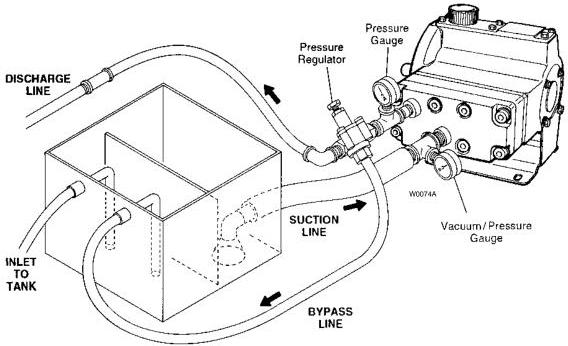

In [13]:
import base64
from IPython.display import Image, display

# Tool results live in response["items"], including retrieved images.
images_shown = 0
seen_images = set()

for item in (response or {}).get("items", []):
    if item.get("type") != "function_call_output":
        continue

    blocks = item.get("output")
    if not isinstance(blocks, list):
        continue

    for block in blocks:
        if not isinstance(block, dict) or block.get("type") not in ("image", "input_image"):
            continue

        url = block.get("image_url", "")
        if not isinstance(url, str) or not url or url in seen_images:
            continue

        if url.startswith("data:"):
            display(Image(data=base64.b64decode(url.split(",", 1)[1]), width=800))
        elif url.startswith(("https://", "http://")):
            display(Image(url=url, embed=True, width=800))
        else:
            continue

        seen_images.add(url)
        images_shown += 1

if not images_shown:
    print("No image results found. Run the query cell above with a question that uses document images.")


## 04 · Review usage & estimated cost (optional)

Inspect the token usage returned for this multimodal query and estimate the model cost using the rate table below. This is a supporting diagnostic for the retrieval-and-understanding example, not a billing total; PageIndex Cloud charges are not included.


In [14]:
import json

# Standard USD per 1M tokens: (input, cached input, output).
# Checked 2026-09-17: https://developers.openai.com/api/docs/models/{model}
PRICES = {
    "gpt-5.6-sol": (4.0, 0.4, 20.0),
    "gpt-5.6-terra": (2.0, 0.2, 12.0),
    "gpt-5.6-luna": (0.2, 0.02, 1.2),
}
input_rate, cached_rate, output_rate = PRICES[MODEL]

usage = response.get("usage") if response else None
print("\n\nUsage:", json.dumps(usage, ensure_ascii=False, indent=2))
if response and response.get("status") != "completed":
    print("Response did not complete:", response.get("error") or response.get("incomplete_details"))

if usage:
    details = usage.get("input_tokens_details") or {}
    cached = details.get("cached_tokens", 0) or 0
    written = details.get("cache_write_tokens", 0) or 0
    regular = usage["input_tokens"] - cached - written
    cost = (regular * input_rate + cached * cached_rate + written * input_rate * 1.25
            + usage["output_tokens"] * output_rate) / 1_000_000
    print(f"Estimated model cost at base rates: ${cost:.6f} USD")
    if usage["input_tokens"] > 272_000:
        print("Usage is aggregated across model calls; the estimate excludes possible long-context surcharges.")
else:
    print("No usage returned; unable to estimate cost.")



Usage: {
  "input_tokens": 25859,
  "input_tokens_details": {
    "cached_tokens": 14772,
    "cache_write_tokens": 11078
  },
  "output_tokens": 693,
  "output_tokens_details": {
    "reasoning_tokens": 125
  },
  "total_tokens": 26552
}
Estimated model cost at base rates: $0.003898 USD


---

<div align="center">
  <br>
  <p>
    <a href="https://docs.pageindex.ai/"><b>Upload your documents</b></a>
    &nbsp;&nbsp; · &nbsp;&nbsp;
    <a href="https://docs.pageindex.ai/sdk/agents"><b>Integrate with your agent</b></a>
    &nbsp;&nbsp; · &nbsp;&nbsp;
    <a href="https://github.com/VectifyAI/PageIndex"><b>Star PageIndex on GitHub</b></a>
  </p>
  <br>
  <a href="https://pageindex.ai">
    <img src="https://github.com/user-attachments/assets/e1c677f2-b590-4ffc-859d-e8cc7d794bdf" width="144" height="40" alt="PageIndex">
  </a>
</div>
